In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# CELL 1: Git Clone & Setup
import os
REPO_URL = "https://github.com/DanielQH07/tranSTR_Casual.git" 
REPO_NAME = "tranSTR_Casual"
BRANCH = "change_feature" 

if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_URL}...")
    !git clone {REPO_URL} -b {BRANCH}
else:
    print("Repo already exists.")

# Change Directory to the repo root 
if os.path.basename(os.getcwd()) != REPO_NAME:
    try:
        target_dir = os.path.join(os.getcwd(), REPO_NAME, "causalvid")
        if os.path.exists(target_dir):
             os.chdir(target_dir)
        elif os.path.exists(REPO_NAME):
             os.chdir(REPO_NAME)
        
        print(f"Changed directory to: {os.getcwd()}")
    except Exception as e:
             print(f"Could not set working directory: {e}")

Cloning https://github.com/DanielQH07/tranSTR_Casual.git...
Cloning into 'tranSTR_Casual'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 169 (delta 90), reused 130 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (169/169), 432.88 KiB | 9.41 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Changed directory to: /kaggle/working/tranSTR_Casual


In [3]:
# CELL 2: Install & Login W&B (với API Key trực tiếp)
print('=== CELL 2: W&B Setup ===')
!pip install -q wandb --upgrade
import wandb

# ============================================
# WANDB CONFIG - THAY THẾ BẰNG API KEY CỦA BẠN
# ============================================
WANDB_API_KEY = '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'  # 🔴 Paste your W&B API key here
WANDB_PROJECT = 'transtr-causalvid-dino'   # Project name on W&B
WANDB_ENTITY = None                        # Your W&B username/team (None = default)

# Login with API key (no interactive prompt)
wandb.login(key=WANDB_API_KEY)
print('✅ W&B logged in successfully!')

=== CELL 2: W&B Setup ===
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 52.7 MB/s eta 0:00:00


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: haidang262004 (haidang262004-i-h-c-qu-c-gia-tp-hcm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ W&B logged in successfully!


In [ ]:
# CELL 3: Imports
print('=== CELL 3: Imports ===')
import os, torch, numpy as np, pandas as pd, json
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from utils.util import set_seed, set_gpu_devices
from DataLoader import VideoQADataset
from networks.model import VideoQAmodel
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
print('Imports OK')

=== CELL 3: Imports ===
Imports OK


In [ ]:
# CELL 4: Train/Eval functions (NCOD bi-level loss + W&B logging)
print('=== CELL 4: Functions (NCOD) ===')

NUM_CHOICES = 5

def train_epoch_ncod(model, opt_model, opt_U, U, loader, device, epoch):
    """Bi-level NCOD training: L1 updates model, L2 updates U."""
    model.train()
    total_l1, total_l2, correct, total = 0, 0, 0, 0

    pbar = tqdm(loader, desc=f'Epoch {epoch}', leave=False)
    for batch_idx, batch in enumerate(pbar):
        ff, of, q, a, ans_id, _qns_key, sample_indices = batch
        ff, of, tgt = ff.to(device), of.to(device), ans_id.to(device)
        sample_indices = sample_indices.long()

        # --- Forward ---
        logits = model(ff, of, q, a)              # [B, 5]
        probs = F.softmax(logits, dim=1)           # [B, 5]

        u_batch = U[sample_indices].unsqueeze(1)   # [B, 1]
        y_onehot = F.one_hot(tgt, num_classes=NUM_CHOICES).float()  # [B, 5]

        # --- L1: update model (U detached) ---
        shifted_probs = probs + (u_batch.detach() * y_onehot)
        shifted_probs = torch.clamp(shifted_probs, min=1e-12, max=1.0)
        L1 = -torch.mean(torch.sum(y_onehot * torch.log(shifted_probs), dim=1))

        opt_model.zero_grad()
        L1.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt_model.step()

        # --- L2: update U (probs detached) ---
        probs_det = probs.detach()
        shifted_det = probs_det + (u_batch * y_onehot)
        L2 = F.mse_loss(shifted_det, y_onehot)

        opt_U.zero_grad()
        L2.backward()
        opt_U.step()

        with torch.no_grad():
            U.clamp_(0.0, 0.99)

        # --- Tracking ---
        total_l1 += L1.item()
        total_l2 += L2.item()
        correct += (logits.argmax(-1) == tgt).sum().item()
        total += tgt.size(0)

        pbar.set_postfix({
            'L1': total_l1 / (batch_idx + 1),
            'L2': total_l2 / (batch_idx + 1),
            'acc': correct / total * 100
        })

        # Log batch metrics to W&B (every 50 batches)
        if batch_idx % 50 == 0:
            wandb.log({
                'batch_L1': L1.item(),
                'batch_L2': L2.item(),
                'batch_acc': (logits.argmax(-1) == tgt).float().mean().item() * 100,
                'batch': epoch * len(loader) + batch_idx
            })

    avg_l1 = total_l1 / len(loader)
    avg_l2 = total_l2 / len(loader)
    acc = correct / total * 100
    return avg_l1, avg_l2, acc


def eval_epoch(model, loader, device):
    """Evaluation — no U involved."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            ff, of, q, a, ans_id, _qns_key, _sample_indices = batch
            out = model(ff.to(device), of.to(device), q, a)
            correct += (out.argmax(-1) == ans_id.to(device)).sum().item()
            total += ans_id.size(0)
    return correct / total * 100

print('Functions defined (NCOD bi-level)!')

=== CELL 4: Functions ===
Functions defined with W&B logging!


In [6]:
# Merge CLIP Features (train/test/valid -> merged folder)
import os
import shutil
from tqdm.auto import tqdm

# ============================================
# 🔴 UPDATE THESE PATHS
# ============================================
CLIP_SPLIT_PATH = '/kaggle/input/feature-full/dinov2_T16_dim1024_full/features'  # Folder chứa train/test/valid
CLIP_MERGED_PATH = '/kaggle/working/dinov2_T16_dim1024_merge'          # Folder output đã gộp

# Check structure
print(f'\nSource: {CLIP_SPLIT_PATH}')
if os.path.exists(CLIP_SPLIT_PATH):
    subfolders = os.listdir(CLIP_SPLIT_PATH)
    print(f'Subfolders found: {subfolders}')
else:
    print('❌ Source path not found!')
    subfolders = []

# Merge folders
os.makedirs(CLIP_MERGED_PATH, exist_ok=True)

total_copied = 0
for split in ['train', 'test', 'valid', 'val']:  # Try common folder names
    split_folder = os.path.join(CLIP_SPLIT_PATH, split)
    if not os.path.exists(split_folder):
        continue
    
    pt_files = [f for f in os.listdir(split_folder) if f.endswith('.pt')]
    print(f'\n📁 {split}: {len(pt_files)} files')
    
    for fname in tqdm(pt_files, desc=f'Copying {split}'):
        src = os.path.join(split_folder, fname)
        dst = os.path.join(CLIP_MERGED_PATH, fname)
        
        # Skip if already exists
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            total_copied += 1

# Summary
final_count = len([f for f in os.listdir(CLIP_MERGED_PATH) if f.endswith('.pt')])
print(f'\n✅ Merge complete!')
print(f'   Total .pt files in merged folder: {final_count}')
print(f'   Merged path: {CLIP_MERGED_PATH}')


Source: /kaggle/input/feature-full/dinov2_T16_dim1024_full/features
Subfolders found: ['valid', 'test', 'train']

📁 train: 18776 files


Copying train:   0%|          | 0/18776 [00:00<?, ?it/s]


📁 test: 5429 files


Copying test:   0%|          | 0/5429 [00:00<?, ?it/s]


📁 valid: 2695 files


Copying valid:   0%|          | 0/2695 [00:00<?, ?it/s]


✅ Merge complete!
   Total .pt files in merged folder: 26900
   Merged path: /kaggle/working/dinov2_T16_dim1024_merge


In [ ]:
# CELL 5: Setup Paths & Config
print('=== CELL 5: Paths & Config ===')

# ============================================
# KAGGLE INPUT PATHS - UPDATE THESE!
# ============================================
CLIP_FEATURE_PATH = CLIP_MERGED_PATH  # 🔴 UPDATE PATH TO YOUR CLIP FEATURES
OBJ_FEATURE_PATH = '/kaggle/input/object-detection-causal-full'
ANNOTATION_PATH = '/kaggle/input/text-annotation/QA'
SPLIT_DIR = '/kaggle/input/casual-vid-data-split/split'

# Working directories
BASE = '/kaggle/working'
MODEL_DIR = os.path.join(BASE, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Verify paths
print('\n--- Path Verification ---')
def verify_path(name, path):
    if os.path.exists(path):
        items = os.listdir(path)[:3]
        print(f'✅ {name}: {items}')
        return True
    else:
        print(f'❌ {name}: NOT FOUND - {path}')
        return False

all_ok = True
all_ok &= verify_path('CLIP Features (1024D)', CLIP_FEATURE_PATH)
all_ok &= verify_path('Object Features', OBJ_FEATURE_PATH)
all_ok &= verify_path('Annotations', ANNOTATION_PATH)
all_ok &= verify_path('Splits', SPLIT_DIR)

if not all_ok:
    print('\n⚠️ Please update paths above!')

# ============================================
# CONFIG
# ============================================
RUN_TRAINING = True
MODEL_FILENAME = 'best_model_dino_ncod.ckpt'

FEAT_DIM = 1024
print(f'\n🔧 Backbone: DINOv2 (D={FEAT_DIM})')

class Config:
    # Paths
    video_feature_root = CLIP_FEATURE_PATH
    object_feature_path = OBJ_FEATURE_PATH
    sample_list_path = ANNOTATION_PATH
    split_dir_txt = SPLIT_DIR
    
    # Model architecture
    topK_frame = 16
    objs = 20
    frames = 16
    select_frames = 5
    topK_obj = 12
    
    frame_feat_dim = FEAT_DIM
    obj_feat_dim = 2053
    d_model = 768
    word_dim = 768
    nheads = 8
    num_encoder_layers = 2
    num_decoder_layers = 2
    normalize_before = True
    activation = 'gelu'
    dropout = 0.3
    encoder_dropout = 0.3
    
    # Text encoder
    text_encoder_type = 'microsoft/deberta-base'
    freeze_text_encoder = False
    text_encoder_lr = 1e-5
    text_pool_mode = 1
    
    # Training
    bs = 8
    lr = 1e-5
    epoch = 20       # 🔴 NCOD cần đủ epoch để U phân tách
    gpu = 0
    patience = 5
    gamma = 0.1
    decay = 1e-4
    n_query = 5
    
    # Other
    hard_eval = False
    pos_ratio = 1.0
    neg_ratio = 1.0
    a = 1.0
    num_workers = 4
    
    # ============================================
    # 🔴 NCOD Hyperparameters
    # ============================================
    ncod_u_lr = 0.1           # SGD learning rate for U (paper appendix)
    ncod_u_mean = 1e-8        # Init mean (very small)
    ncod_u_std = 1e-9         # Init std (very small)
    ncod_u_clamp_max = 0.99   # Upper bound (Theorem 5.1)

args = Config()
set_gpu_devices(args.gpu)
set_seed(999)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')
print(f'Config loaded! frame_feat_dim = {args.frame_feat_dim}')
print(f'NCOD: U_lr={args.ncod_u_lr}, clamp_max={args.ncod_u_clamp_max}')

=== CELL 5: Paths & Config ===

--- Path Verification ---
✅ CLIP Features (1024D): ['9lyMzPF5Yw0_000017_000027.pt', 'ZCwr-mdezI4_000054_000064.pt', 'KRPmdsgg_m4_000005_000015.pt']
✅ Object Features: ['features_node_4_FULL', 'features_node_5_FULL', 'features_node_2_FULL']
✅ Annotations: ['P-JmNb-FcLk_000041_000051', '2VBmRPrfNZY_000000_000010', '_muKn2ZeLK0_000018_000028']
✅ Splits: ['valid.pkl', 'train.pkl', 'test.pkl']

🔧 Backbone: openai/dinov2 (D=1024)

Device: cuda
Config loaded! frame_feat_dim = 1024


In [8]:
# CELL 6: Create Datasets
print('=== CELL 6: Datasets ===')

MAX_TRAIN_SAMPLES = None  # Change to None for all samples

print('\n--- Creating TRAIN dataset ---')
train_ds = VideoQADataset(
    split='train', n_query=args.n_query, obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    object_feature_path=args.object_feature_path,
    split_dir=args.split_dir_txt, topK_frame=args.topK_frame,
    max_samples=MAX_TRAIN_SAMPLES, verbose=True
)

print('\n--- Creating VAL dataset ---')
val_ds = VideoQADataset(
    split='val', n_query=args.n_query, obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    object_feature_path=args.object_feature_path,
    split_dir=args.split_dir_txt, topK_frame=args.topK_frame,
    max_samples=None, verbose=True
)

print('\n--- Creating TEST dataset ---')
test_ds = VideoQADataset(
    split='test', n_query=args.n_query, obj_num=args.objs,
    sample_list_path=args.sample_list_path,
    video_feature_path=args.video_feature_root,
    object_feature_path=args.object_feature_path,
    split_dir=args.split_dir_txt, topK_frame=args.topK_frame,
    max_samples=None, verbose=True
)

train_loader = DataLoader(train_ds, args.bs, shuffle=True, num_workers=args.num_workers, pin_memory=True)
val_loader = DataLoader(val_ds, args.bs, shuffle=False, num_workers=args.num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, args.bs, shuffle=False, num_workers=args.num_workers, pin_memory=True)

print('\n' + '='*60)
print('DATASET SUMMARY')
print('='*60)
print(f'Train: {len(train_ds)} samples -> {len(train_loader)} batches')
print(f'Val:   {len(val_ds)} samples -> {len(val_loader)} batches')
print(f'Test:  {len(test_ds)} samples -> {len(test_loader)} batches')
print(f'Feature dim: {args.frame_feat_dim} (Dinov2)')
print('='*60)

=== CELL 6: Datasets ===

--- Creating TRAIN dataset ---
[train] Object feature format: kaggle_subdirs
[train] Indexed 26900 object features, 26900 ViT features
[train] Loaded 18776 video IDs from /kaggle/input/casual-vid-data-split/split/train.pkl
[train] ViT: 18776, Obj: 18776, Both: 18776


[train] Parsing annotations:   0%|          | 0/18776 [00:00<?, ?it/s]

[train] Final: 112656 QA pairs

--- Creating VAL dataset ---
[val] Object feature format: kaggle_subdirs
[val] Indexed 26900 object features, 26900 ViT features
[val] Loaded 2695 video IDs from /kaggle/input/casual-vid-data-split/split/valid.pkl
[val] ViT: 2695, Obj: 2695, Both: 2695


[val] Parsing annotations:   0%|          | 0/2695 [00:00<?, ?it/s]

[val] Final: 16170 QA pairs

--- Creating TEST dataset ---
[test] Object feature format: kaggle_subdirs
[test] Indexed 26900 object features, 26900 ViT features
[test] Loaded 5429 video IDs from /kaggle/input/casual-vid-data-split/split/test.pkl
[test] ViT: 5429, Obj: 5429, Both: 5429


[test] Parsing annotations:   0%|          | 0/5429 [00:00<?, ?it/s]

[test] Final: 32574 QA pairs

DATASET SUMMARY
Train: 112656 samples -> 14082 batches
Val:   16170 samples -> 2022 batches
Test:  32574 samples -> 4072 batches
Feature dim: 1024 (Dinov2)


In [ ]:
# CELL 7: Model + NCOD U + Dual Optimizers
print('=== CELL 7: Model + NCOD ===')
cfg = {k: v for k, v in Config.__dict__.items() if not k.startswith('_')}
cfg['device'] = device
cfg['topK_frame'] = args.select_frames

print(f'Creating model with frame_feat_dim = {cfg["frame_feat_dim"]}')

model = VideoQAmodel(**cfg)
model.to(device)

# ============================================
# 🔴 NCOD: Khởi tạo U và dual optimizers
# ============================================
num_train_samples = len(train_ds)
print(f'\n🔧 NCOD: Initializing U for {num_train_samples} training samples')

U = torch.nn.Parameter(
    torch.abs(torch.randn(num_train_samples) * args.ncod_u_std + args.ncod_u_mean)
).to(device)

# Optimizer 1: Model parameters (AdamW, separate LR for text encoder)
opt_model = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters()
                if "text_encoder" not in n and p.requires_grad]},
    {"params": [p for n, p in model.named_parameters()
                if "text_encoder" in n and p.requires_grad],
     "lr": args.text_encoder_lr}
], lr=args.lr, weight_decay=args.decay)

# Optimizer 2: U parameter (SGD, paper appendix)
opt_U = torch.optim.SGD([U], lr=args.ncod_u_lr)

scheduler = ReduceLROnPlateau(opt_model, 'max', factor=args.gamma, patience=args.patience)
save_path = os.path.join(MODEL_DIR, MODEL_FILENAME)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params/1e6:.1f}M')
print(f'Trainable:    {trainable_params/1e6:.1f}M')
print(f'U shape:      [{num_train_samples}]')
print(f'U init range: [{U.min().item():.2e}, {U.max().item():.2e}]')

=== CELL 7: Model ===
Creating model with frame_feat_dim = 1024


config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

2026-02-04 06:18:48.669479: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770185929.047314      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770185929.152724      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770185930.041826      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770185930.041865      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770185930.041868      25 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

Total params: 215.6M
Trainable:    215.6M


In [ ]:
# CELL 8: Initialize W&B Run
print('=== CELL 8: Initialize W&B Run ===')

# Create W&B config dict
wandb_config = {
    'model': 'TranSTR',
    'backbone': 'openai/dinov2_T16_dim1024',
    'frame_feat_dim': args.frame_feat_dim,
    'text_encoder': args.text_encoder_type,
    'batch_size': args.bs,
    'learning_rate': args.lr,
    'epochs': args.epoch,
    'max_train_samples': MAX_TRAIN_SAMPLES,
    'd_model': args.d_model,
    'nheads': args.nheads,
    'num_encoder_layers': args.num_encoder_layers,
    'num_decoder_layers': args.num_decoder_layers,
    'dropout': args.dropout,
    'topK_frame': args.select_frames,
    'topK_obj': args.topK_obj,
    'train_samples': len(train_ds),
    'val_samples': len(val_ds),
    'test_samples': len(test_ds),
    # 🔴 NCOD config
    'ncod_enabled': True,
    'ncod_u_lr': args.ncod_u_lr,
    'ncod_u_clamp_max': args.ncod_u_clamp_max,
    'ncod_u_mean': args.ncod_u_mean,
    'ncod_u_std': args.ncod_u_std,
}

# Initialize W&B run
run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    config=wandb_config,
    name=f'transtr-dino1024-ncod-ep{args.epoch}-bs{args.bs}',
    reinit=True
)

# Watch model for gradient logging
wandb.watch(model, log='gradients', log_freq=100)

print(f'✅ W&B Run initialized: {run.url}')

=== CELL 8: Initialize W&B Run ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: Tracking run with wandb version 0.24.1
wandb: Run data is saved locally in /kaggle/working/tranSTR_Casual/wandb/run-20260204_061912-y79t6n65
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run transtr-dinov21024-ep5-bs8
wandb: ⭐️ View project at https://wandb.ai/haidang262004-i-h-c-qu-c-gia-tp-hcm/transtr-causalvid-dino
wandb: 🚀 View run at https://wandb.ai/haidang262004-i-h-c-qu-c-gia-tp-hcm/transtr-causalvid-dino/runs/y79t6n65


✅ W&B Run initialized: https://wandb.ai/haidang262004-i-h-c-qu-c-gia-tp-hcm/transtr-causalvid-dino/runs/y79t6n65


In [ ]:
# CELL 9: NCOD Training with W&B Logging
print('=== CELL 9: NCOD Training ===')

best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

if RUN_TRAINING:
    for ep in range(1, args.epoch + 1):
        print(f'\nEpoch {ep}/{args.epoch}')
        
        # Train with NCOD bi-level optimization
        loss, train_acc = train_epoch_ncod(
            model, opt_model, opt_U, U, train_loader, device, ep
        )
        
        # Validate
        val_acc = eval_epoch(model, val_loader, device)
        scheduler.step(val_acc)
        
        # Log to history
        history['train_loss'].append(loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # 🔴 NCOD: U statistics
        u_data = U.detach().cpu()
        u_stats = {
            'epoch': ep,
            'train_loss': loss,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'learning_rate': opt_model.param_groups[0]['lr'],
            'best_val_acc': max(best_acc, val_acc),
            # NCOD U stats
            'U/mean': u_data.mean().item(),
            'U/std':  u_data.std().item(),
            'U/max':  u_data.max().item(),
            'U/min':  u_data.min().item(),
            'U/pct_gt_0.5': (u_data > 0.5).float().mean().item() * 100,
            'U/pct_gt_0.9': (u_data > 0.9).float().mean().item() * 100,
            'U/histogram': wandb.Histogram(u_data.numpy()),
        }
        wandb.log(u_stats)
        
        print(f'Loss: {loss:.4f} | Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')
        print(f'  U: mean={u_data.mean():.4e} max={u_data.max():.4e} '
              f'>0.5={u_stats["U/pct_gt_0.5"]:.1f}% >0.9={u_stats["U/pct_gt_0.9"]:.1f}%')
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            # Save model + U together
            torch.save({
                'model_state_dict': model.state_dict(),
                'U': U.detach().cpu(),
                'epoch': ep,
                'val_acc': val_acc,
            }, save_path)
            print(f'✅ New best! Saved to {save_path}')
            
            # 📦 LOG CHECKPOINT TO W&B
            artifact = wandb.Artifact(
                name='best-model-dino-ncod',
                type='model',
                description=f'Best NCOD model at epoch {ep} with val_acc={val_acc:.2f}%',
                metadata={
                    'epoch': ep,
                    'val_acc': val_acc,
                    'train_acc': train_acc,
                    'train_loss': loss,
                    'backbone': 'dinov2_T16_dim1024',
                    'frame_feat_dim': FEAT_DIM,
                    'ncod_u_mean': u_data.mean().item(),
                    'ncod_u_max': u_data.max().item(),
                }
            )
            artifact.add_file(save_path)
            wandb.log_artifact(artifact)
            print(f'📤 Checkpoint uploaded to W&B!')
    
    print(f'\n🏆 Best Val Accuracy: {best_acc:.1f}%')
    
    # Log final summary
    wandb.run.summary['best_val_acc'] = best_acc
    wandb.run.summary['final_train_loss'] = history['train_loss'][-1]
    wandb.run.summary['final_U_mean'] = u_data.mean().item()
    wandb.run.summary['final_U_max'] = u_data.max().item()

=== CELL 9: Training ===

Epoch 1/5


Epoch 1:   0%|          | 0/14082 [00:00<?, ?it/s]

Loss: 1.1259 | Train: 53.8% | Val: 49.2%
✅ New best! Saved to /kaggle/working/models/best_model_dino_full.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 2/5


Epoch 2:   0%|          | 0/14082 [00:00<?, ?it/s]

Loss: 0.8445 | Train: 69.6% | Val: 55.8%
✅ New best! Saved to /kaggle/working/models/best_model_dino_full.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 3/5


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7962f1185bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7962f1185bc0>
^^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
^    
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers

     if w.is_alive():
                ^^^ ^^^^^^^^^^^^^^^^^^^^^


Loss: 0.6284 | Train: 79.9% | Val: 57.9%
✅ New best! Saved to /kaggle/working/models/best_model_dino_full.ckpt
📤 Checkpoint uploaded to W&B!

Epoch 5/5


Epoch 5:   0%|          | 0/14082 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7962f1185bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7962f1185bc0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Loss: 0.5680 | Train: 82.5% | Val: 58.1%
✅ New best! Saved to /kaggle/working/models/best_model_dino_full.ckpt
📤 Checkpoint uploaded to W&B!

🏆 Best Val Accuracy: 58.1%


=== CELL 10: Detailed Evaluation ===

📌 Using VALIDATION SET for evaluation

📊 Running Detailed Evaluation...


  0%|          | 0/2022 [00:00<?, ?it/s]


EVALUATION RESULTS
Description               ==>   70.46%  (1899/2695)
Explanation               ==>   73.47%  (1980/2695)
Predictive-Answer         ==>   55.44%  (1494/2695)
Predictive-Reason         ==>   51.39%  (1385/2695)
Counterfactual-Answer     ==>   61.63%  (1661/2695)
Counterfactual-Reason     ==>   35.99%  (970/2695)
------------------------------------------------------------
PAR                       ==>   34.43%  (928/2695 paired)
CAR                       ==>   24.64%  (664/2695 paired)
------------------------------------------------------------
Acc (ALL)                 ==>   50.75%  ((D+E+PAR+CAR)/4)
📤 Metrics logged to W&B!


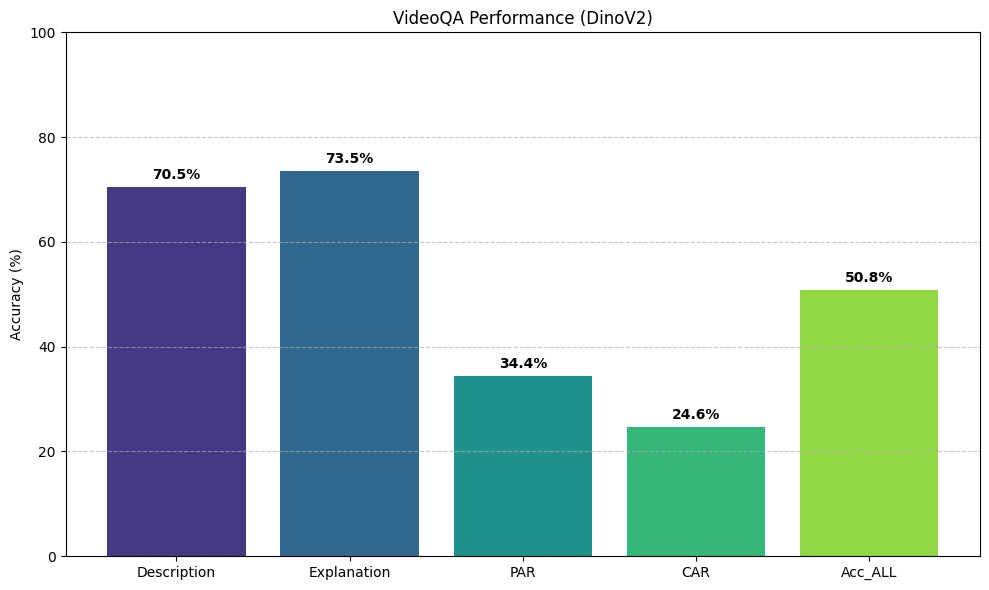

In [ ]:
# CELL 10: Detailed Evaluation with W&B Logging
print('=== CELL 10: Detailed Evaluation ===')
import seaborn as sns

def evaluate_detailed_v2(model, loader, device, log_to_wandb=True):
    """Tính metric trực tiếp từ batch với W&B logging."""
    model.eval()
    type_results = {}
    
    print("\n📊 Running Detailed Evaluation...")
    with torch.no_grad():
        for batch in tqdm(loader):
            ff, of, qns, ans_word, ans_id, qns_keys, _sample_indices = batch
            ff, of = ff.to(device), of.to(device)
            
            out = model(ff, of, qns, ans_word)
            preds = out.argmax(dim=-1).cpu().numpy()
            targets = ans_id.numpy()
            
            for key, pred, target in zip(qns_keys, preds, targets):
                # Parse key to get video_id and type
                if key.endswith('_reason'):
                    if '_predictive_reason' in key:
                        idx = key.rfind('_predictive_reason')
                        video_id, qtype = key[:idx], 'predictive_reason'
                    elif '_counterfactual_reason' in key:
                        idx = key.rfind('_counterfactual_reason')
                        video_id, qtype = key[:idx], 'counterfactual_reason'
                    else:
                        parts = key.rsplit('_', 2)
                        video_id = parts[0] if len(parts) > 2 else key
                        qtype = '_'.join(parts[1:]) if len(parts) > 1 else 'unknown'
                else:
                    parts = key.rsplit('_', 1)
                    video_id, qtype = parts if len(parts) == 2 else (key, 'unknown')
                
                if qtype not in type_results:
                    type_results[qtype] = []
                type_results[qtype].append({
                    'video_id': video_id,
                    'pred': int(pred),
                    'target': int(target),
                    'correct': int(pred) == int(target)
                })
    
    # Calculate metrics
    metrics = {}
    metrics_map = {
        'Description': 'descriptive',
        'Explanation': 'explanatory',
        'Predictive-Answer': 'predictive',
        'Predictive-Reason': 'predictive_reason',
        'Counterfactual-Answer': 'counterfactual',
        'Counterfactual-Reason': 'counterfactual_reason'
    }
    
    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    
    for name, qtype in metrics_map.items():
        if qtype in type_results:
            results = type_results[qtype]
            correct = sum(1 for r in results if r['correct'])
            total = len(results)
            acc = correct / total * 100 if total > 0 else 0
        else:
            correct, total, acc = 0, 0, 0
        metrics[name] = acc
        print(f"{name:<25} ==>   {acc:.2f}%  ({correct}/{total})")
    
    # Hard Metrics
    print("-" * 60)
    
    def calc_hard_metric(type_ans, type_reason, name):
        if type_ans not in type_results or type_reason not in type_results:
            metrics[name] = 0
            print(f"{name:<25} ==>   0.00%  (0/0 paired)")
            return
        
        ans_by_vid = {r['video_id']: r['correct'] for r in type_results[type_ans]}
        reason_by_vid = {r['video_id']: r['correct'] for r in type_results[type_reason]}
        common_vids = set(ans_by_vid.keys()) & set(reason_by_vid.keys())
        
        both_correct = sum(1 for vid in common_vids if ans_by_vid[vid] and reason_by_vid[vid])
        total = len(common_vids)
        acc = both_correct / total * 100 if total > 0 else 0
        metrics[name] = acc
        print(f"{name:<25} ==>   {acc:.2f}%  ({both_correct}/{total} paired)")
    
    calc_hard_metric('predictive', 'predictive_reason', 'PAR')
    calc_hard_metric('counterfactual', 'counterfactual_reason', 'CAR')
    
    print("-" * 60)
    
    # Acc (ALL)
    d_acc = metrics.get('Description', 0)
    e_acc = metrics.get('Explanation', 0)
    par_acc = metrics.get('PAR', 0)
    car_acc = metrics.get('CAR', 0)
    acc_all = (d_acc + e_acc + par_acc + car_acc) / 4
    metrics['Acc_ALL'] = acc_all
    print(f"{'Acc (ALL)':<25} ==>   {acc_all:.2f}%  ((D+E+PAR+CAR)/4)")
    print("="*60)
    
    # 📊 LOG FINAL METRICS TO W&B
    if log_to_wandb:
        wandb.log({
            'eval/Description': metrics['Description'],
            'eval/Explanation': metrics['Explanation'],
            'eval/Predictive_Answer': metrics['Predictive-Answer'],
            'eval/Predictive_Reason': metrics['Predictive-Reason'],
            'eval/Counterfactual_Answer': metrics['Counterfactual-Answer'],
            'eval/Counterfactual_Reason': metrics['Counterfactual-Reason'],
            'eval/PAR': metrics['PAR'],
            'eval/CAR': metrics['CAR'],
            'eval/Acc_ALL': acc_all
        })
        
        # Log summary
        wandb.run.summary['eval_Description'] = metrics['Description']
        wandb.run.summary['eval_Explanation'] = metrics['Explanation']
        wandb.run.summary['eval_PAR'] = metrics['PAR']
        wandb.run.summary['eval_CAR'] = metrics['CAR']
        wandb.run.summary['eval_Acc_ALL'] = acc_all
        print('📤 Metrics logged to W&B!')
    
    # Plot
    keys = ['Description', 'Explanation', 'PAR', 'CAR', 'Acc_ALL']
    values = [metrics.get(k, 0) for k in keys]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(keys, values, color=sns.color_palette("viridis", len(keys)))
    ax.set_ylim(0, 100)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('VideoQA Performance (DinoV2)')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    
    # Log chart to W&B
    if log_to_wandb:
        wandb.log({'eval_chart': wandb.Image(fig)})
    
    plt.savefig('eval_results_dinov2.png')
    plt.show()
    
    return metrics, type_results

# Run evaluation on VALIDATION set (has ground truth)
print("\n📌 Using VALIDATION SET for evaluation")
metrics, raw_results = evaluate_detailed_v2(model, val_loader, device, log_to_wandb=True)

In [13]:
# CELL 11: Finish W&B Run
print('=== CELL 11: Finish W&B ===')

# Save metrics locally
with open('final_metrics_dino.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved: final_metrics_dino.json')

# Log final artifact with all results
final_artifact = wandb.Artifact(
    name='final-results-dino',
    type='results',
    description='Final evaluation results and metrics (Dinov2)',
    metadata={
        'backbone': 'dinov2',
        'frame_feat_dim': FEAT_DIM
    }
)
final_artifact.add_file('final_metrics_dino.json')
final_artifact.add_file('eval_results_dinov2.png')
if os.path.exists(save_path):
    final_artifact.add_file(save_path)
wandb.log_artifact(final_artifact)

# Finish run
wandb.finish()
print('\n✅ W&B run finished!')
print(f'View results at: https://wandb.ai/{WANDB_ENTITY or "your-username"}/{WANDB_PROJECT}')

=== CELL 11: Finish W&B ===
Saved: final_metrics_dino.json


wandb: uploading artifact final-results-dino; updating run metadata
wandb: uploading artifact final-results-dino; uploading wandb-summary.json; uploading config.yaml
wandb: uploading artifact final-results-dino; uploading wandb-summary.json
wandb: uploading artifact final-results-dino
wandb: uploading artifact final-results-dino; uploading history steps 1415-1416, summary, console lines 34-52
wandb: uploading artifact final-results-dino
wandb: 
wandb: Run history:
wandb:                      batch ▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
wandb:                  batch_acc ▂▆▅▅▁▂▆▆▆▃▃▇▆▅▆▇▆▅█▇▆▇▆▆▆▆▆▆▅▆▆▇█▇▆▇▆█▇▇
wandb:                 batch_loss ▆▅▆▆█▄▄▇▄▄▆▆▅▃▇▂▂▂▃▃▇▃▆▁▅▄▆▂▅▂▂▃▃▃▃▃▆▅▂▁
wandb:               best_val_acc ▁▆▇██
wandb:                      epoch ▁▃▅▆█
wandb:               eval/Acc_ALL ▁
wandb:                   eval/CAR ▁
wandb: eval/Counterfactual_Answer ▁
wandb: eval/Counterfactual_Reason ▁
wandb:           eval/Description ▁
wandb:                         +8 ...
wandb: 



✅ W&B run finished!
View results at: https://wandb.ai/your-username/transtr-causalvid-dino


In [ ]:
# CELL 12: 🔴 NCOD - Noisy Sample Analysis
print('=== CELL 12: Noisy Sample Analysis ===')
import pandas as pd

u_np = U.detach().cpu().numpy()
top_k_noisy = 100

# Sort by U descending (high U = likely noisy)
sorted_indices = u_np.argsort()[::-1][:top_k_noisy]

rows = []
for rank, idx in enumerate(sorted_indices):
    sample = train_ds[idx]
    # raw text branch: ff, of, qns, ans_word, ans_id, qns_key, idx
    qns_key = sample[-2]  # qns_key is second to last
    rows.append({
        'rank': rank + 1,
        'sample_idx': int(idx),
        'U_value': float(u_np[idx]),
        'qns_key': qns_key,
    })

df_noisy = pd.DataFrame(rows)

print(f'\n🔍 Top-{top_k_noisy} noisiest samples (highest U):')
print(df_noisy.head(20).to_string(index=False))

# Save CSV
csv_path = 'ncod_noisy_samples.csv'
df_noisy.to_csv(csv_path, index=False)
print(f'\n💾 Saved: {csv_path}')

# U distribution stats
print(f'\n📊 U Distribution (all {len(u_np)} samples):')
print(f'  mean={u_np.mean():.4e}  std={u_np.std():.4e}')
print(f'  min={u_np.min():.4e}   max={u_np.max():.4e}')
print(f'  >0.5: {(u_np > 0.5).sum()} ({(u_np > 0.5).mean()*100:.1f}%)')
print(f'  >0.9: {(u_np > 0.9).sum()} ({(u_np > 0.9).mean()*100:.1f}%)')

# Plot U histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(u_np, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('U value')
axes[0].set_ylabel('Count')
axes[0].set_title('U Distribution (all samples)')
axes[0].axvline(x=0.5, color='r', linestyle='--', label='0.5 threshold')
axes[0].legend()

axes[1].hist(u_np[u_np > 0.01], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('U value')
axes[1].set_ylabel('Count')
axes[1].set_title('U Distribution (U > 0.01 only)')

plt.tight_layout()
plt.savefig('ncod_u_distribution.png')
plt.show()

print('\n✅ Noisy sample analysis complete!')